## **Introduction to Integer Programming and Applications with Julia**

<table>
  <tr>
    <td>Chapter</td>
    <td>8 - Branch-and-Bound</td>
  </tr>
  <tr>
    <td>Author(s)</td>
    <td>Luiz Henrique Nogueira Lorena</td>
  </tr>
</table>

---

## Exercise 8.1

Solve the following Binary Knapsack Problem instance using the Branch-and-Bound technique.

$$
𝑣 = \begin{pmatrix}
8, 16, 20, 12, 6, 10, 4
\end{pmatrix}
\quad
𝑤 = \begin{pmatrix}
3, 7, 9, 6, 3, 5, 2
\end{pmatrix}
\quad
𝑊 = 17
$$

The incumbent heuristic implemented here is:

1. Compute the value/weight ratio for each item.
2. Sort items by decreasing ratio.
3. Insert items greedily while capacity allows.

### a) Solving using DFS search strategy 

========== Branch-and-Bound Completed ==========

Total time: 0.1189730167388916 seconds
Best solution: [1.0, -0.0, 1.0, 0.0, 0.0, 1.0, -0.0]
Objective value: 38.0

Nodes explored: 15
Nodes pruned: 7
Pruning statistics:
	- Pruned by infeasibility: 5
	- Pruned by integrality: 1
	- Pruned by bound: 1

Search Tree

└── Node 1 (39.56) 
    ├── Node 2 (38.0) ✂️
    └── Node 3 (39.43) 
        ├── Node 4 (38.0) ⭐
        └── Node 5 (38.67) 
            ├── Node 6 (38.0) 
            │   ├── Node 8 (38.0) 
            │   │   ├── Node 10 (38.0) 
            │   │   │   ├── Node 12 (38.0) 
            │   │   │   │   ├── Node 14 (36.0) 🔒
            │   │   │   │   └── Node 15 (-Inf) 🚫
            │   │   │   └── Node 13 (-Inf) 🚫
            │   │   └── Node 11 (-Inf) 🚫
            │   └── Node 9 (-Inf) 🚫
            └── Node 7 (-Inf) 🚫

Legend:

	🔒 : Pruned by Integrality
	🚫 : Pruned by Infeasibility
	✂️ : Pruned by Bound
	⭐ : Optimal



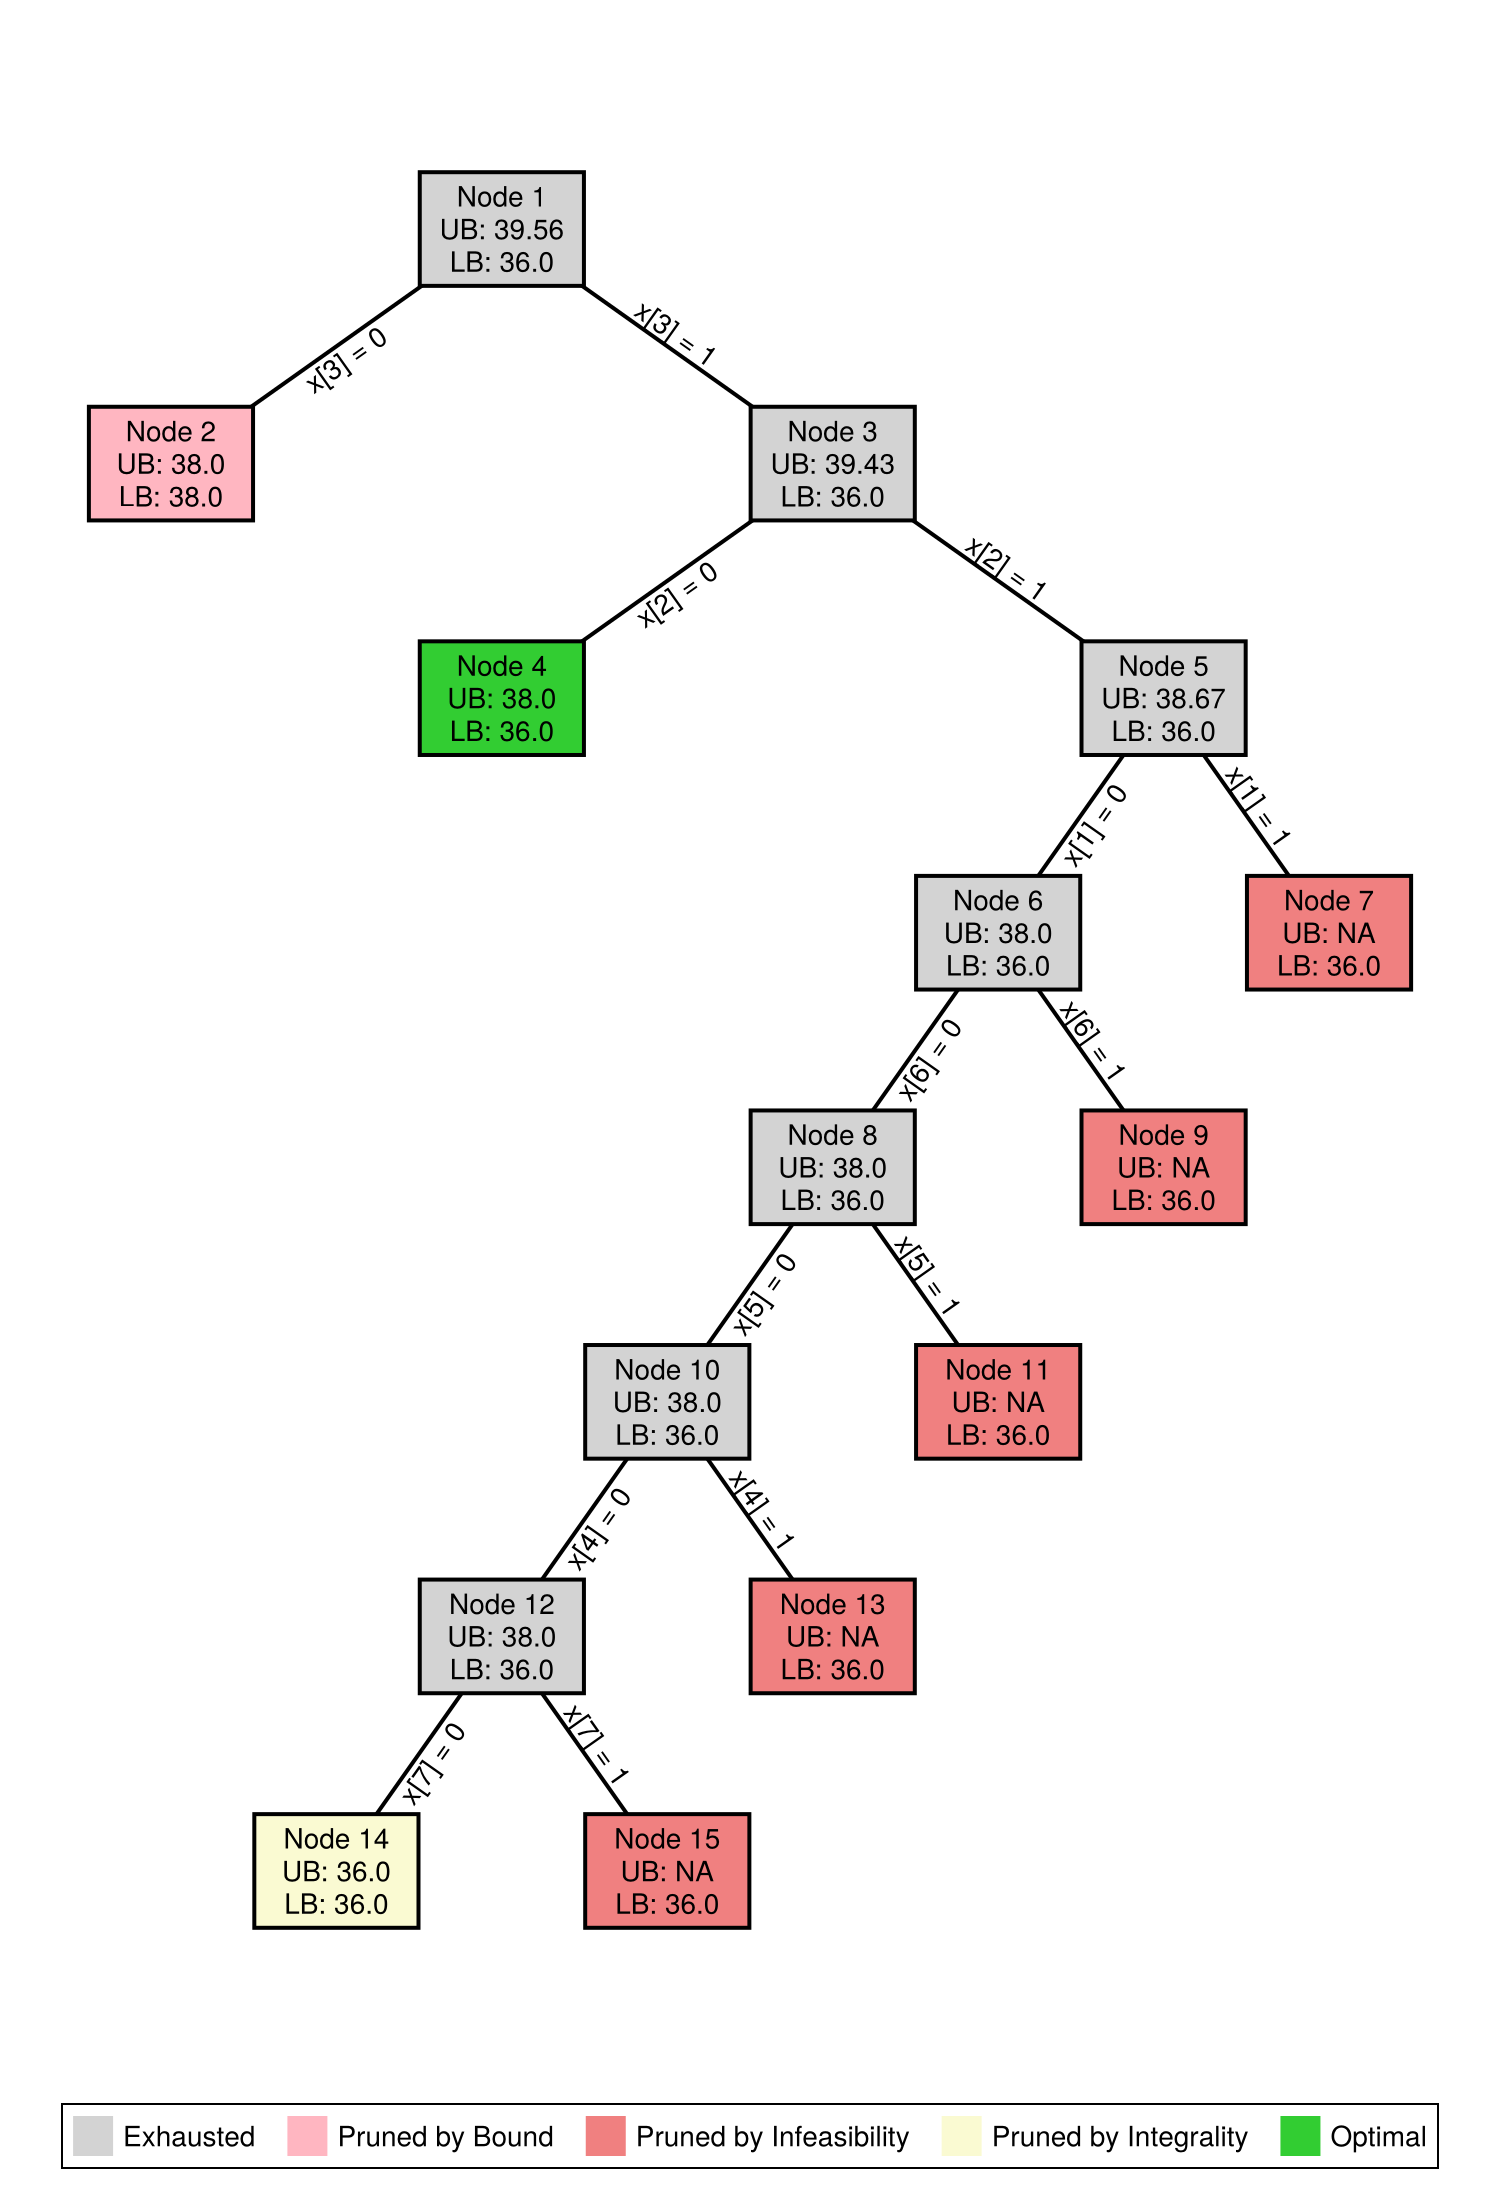

In [11]:
using BnB   # BnB Framework
using JuMP  # Modeling language
using HiGHS # Solver

# Structure to represent the BKP data
struct BKPData <: BnB.BnBData
    v::Vector{Int64} # values
    w::Vector{Int64} # weights
    W::Int64         # capacity
    n::Int           # number of items
    # Constructor
    function BKPData(;v::Vector{Int64}, w::Vector{Int64}, W::Int64)
        return new(v, w, W, length(v))
    end
end

# Structure to represent the branch constraint
struct FixVariable <: BnB.BnBBranchConstraint
    i::Int64     # Variable index
    value::Int64 # Value to fix
end

# Function to find an initial incumbent solution using a greedy heuristic based on value-to-weight ratio
function BnB.custom_incumbent(data::BKPData)
    # Value-to-weight ratios
    ratios = data.v ./ data.w
    # Sort items by decreasing ratio
    order = sortperm(ratios, rev=true)
    # Initialize solution vector
    solution = zeros(Int, data.n)
    # Greedy filling based on sorted order
    remaining_capacity = data.W
    incumbent_objective = 0.0
    for i in order
        if data.w[i] <= remaining_capacity
            solution[i] = 1
            remaining_capacity -= data.w[i]
            incumbent_objective += data.v[i]
        end
    end
    return BnB.BnBSolution(solution=solution, objective=incumbent_objective)
end

# Function to solve the LP relaxation of the BKP for a given node
function BnB.custom_relaxation(node::BnB.BnBNode, bnb::BnB.BnBCore)
    model = JuMP.Model(HiGHS.Optimizer)
    JuMP.set_silent(model)
    @variable(model, 0 <= x[i in 1:bnb.data.n] <= 1)
    @objective(model, Max, sum(bnb.data.v[i] * x[i] for i in 1:bnb.data.n))
    @constraint(model, sum(bnb.data.w[i] * x[i] for i in 1:bnb.data.n) <= bnb.data.W)
    # Add constraints for fixed variables
    for branch in node.branch_constraints
        @constraint(model, x[branch.i] == branch.value)
    end
    JuMP.optimize!(model)
    if JuMP.termination_status(model) == JuMP.OPTIMAL
        return BnB.BnBSolution(solution=JuMP.value.(x), objective=JuMP.objective_value(model))
    end
end

# Function to check pruning conditions for a given node and update its status accordingly
function BnB.custom_prune(node::BnB.BnBNode, bnb::BnB.BnBCore)
    # 1. Prune by Infeasibility
    if isnothing(node.relaxation.solution)
        return BnB.PrunedByInfeasibility
    end
    # 2. Prune by Integrality
    if !any(x -> 1e-5 < x < (1 - 1e-5), node.relaxation.solution)
        return BnB.PrunedByIntegrality
    end
    # 3. Prune by Bound
    if node.relaxation.objective <= bnb.incumbent.objective
        return BnB.PrunedByBound
    end
    return BnB.Active
end

# Function to select the branches and the values to fix for a given node
function BnB.custom_branch(node::BnB.BnBNode, bnb::BnB.BnBCore)
    # Create two branches: one excluding the edge and one including the edge
    branch_constraints = Vector{BnB.BnBBranchConstraint}()
    # Find all fractional variables in the solution
    fractional_variables = findall(x -> 1e-5 < x < (1 - 1e-5), node.relaxation.solution)
    # Create branches
    for var in fractional_variables
        left_branch = FixVariable(var, 0)
        right_branch = FixVariable(var, 1)
        # Check if the variable is already fixed to 0.0 in the current node
        if left_branch in node.branch_constraints || right_branch in node.branch_constraints
            continue
        end
        push!(branch_constraints, left_branch)  # Left branch: exclude the item
        push!(branch_constraints, right_branch) # Right branch: include the item
        return branch_constraints
    end
end

# Function to determine if a node contains an optimal solution
function BnB.custom_is_optimal_solution(node::BnB.BnBNode, bnb::BnB.BnBCore)
    # Check if the node has a valid solution
    if isnothing(node.relaxation.solution)
        return false
    end
    # Check if the solution is integral (i.e., all variables are either 0 or 1)
    is_integral = !any(x -> 1e-5 < x < (1 - 1e-5), node.relaxation.solution)
    # Check if the relaxation value matches the best incumbent objective value within a tolerance
    is_optimal = isapprox(node.relaxation.objective, bnb.incumbent.objective; atol=1e-6)
    # It is optimal if it has an integral solution and its relaxation value matches the incumbent objective value
    if is_integral && is_optimal
        return true
    end
    return false
end

# Example
data = BKPData(
    v = [8, 16, 20, 12, 6, 10, 4],
    w = [3, 7, 9, 6, 3, 5, 2],
    W = 17
)

# Define plot options for this example
custom_plot_options = BnB.BnBPlotOptions(
    figure_size = (750, 1100),
    node_size = (130, 90),
    node_label_size = 14,
    edge_label_size = 14,
    show_legend = true,
    legend_position = :bottom,
    branch_label = (branch::FixVariable) -> "x[$(branch.i)] = $(branch.value)"
)

# Solve the BKP using the BnB framework
solution = BnB.solve(data, is_maximization = true, search_strategy = :dfs, custom_plot_options = custom_plot_options);

### b) Solve using Best Bound search strategy

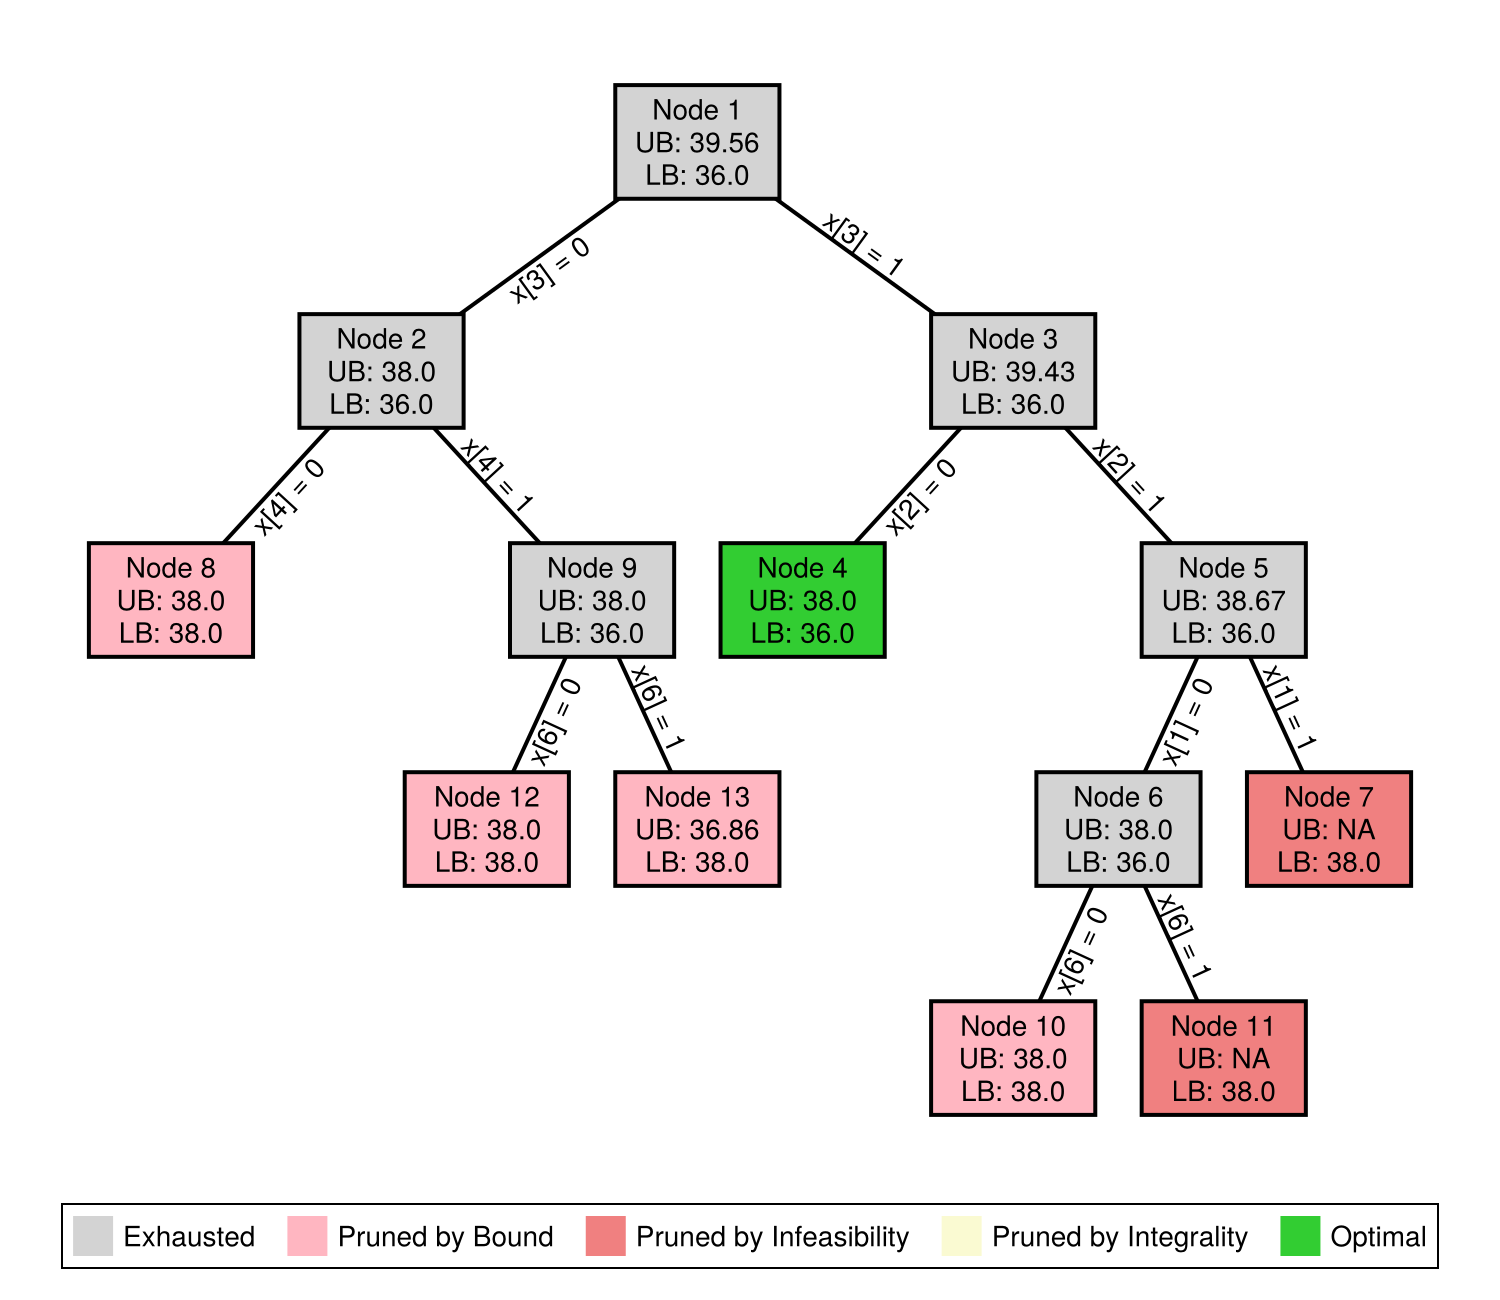

========== Branch-and-Bound Completed ==========

Total time: 0.02105402946472168 seconds
Best solution: [1.0, -0.0, 1.0, 0.0, 0.0, 1.0, -0.0]
Objective value: 38.0

Nodes explored: 13
Nodes pruned: 6
Pruning statistics:
	- Pruned by infeasibility: 2
	- Pruned by integrality: 0
	- Pruned by bound: 4

Search Tree

└── Node 1 (39.56) 
    ├── Node 2 (38.0) 
    │   ├── Node 8 (38.0) ✂️
    │   └── Node 9 (38.0) 
    │       ├── Node 12 (38.0) ✂️
    │       └── Node 13 (36.86) ✂️
    └── Node 3 (39.43) 
        ├── Node 4 (38.0) ⭐
        └── Node 5 (38.67) 
            ├── Node 6 (38.0) 
            │   ├── Node 10 (38.0) ✂️
            │   └── Node 11 (-Inf) 🚫
            └── Node 7 (-Inf) 🚫

Legend:

	🔒 : Pruned by Integrality
	🚫 : Pruned by Infeasibility
	✂️ : Pruned by Bound
	⭐ : Optimal



In [12]:
# Define plot options for this example
custom_plot_options = BnB.BnBPlotOptions(
    figure_size = (750, 650),
    node_size = (130, 90),
    node_label_size = 14,
    edge_label_size = 14,
    show_legend = true,
    legend_position = :bottom,
    branch_label = (branch::FixVariable) -> "x[$(branch.i)] = $(branch.value)"
)

# Solve the BKP using the BnB framework
solution = BnB.solve(data, is_maximization = true, search_strategy = :best_bound, custom_plot_options = custom_plot_options);

### c) Compare the results obtained in exercises a) and b). Is there an advantage of using the Best Bound search strategy instead of the DFS for this instance of the BKP?

Yes. Based on these results, the **Best Bound** strategy appears to have a clear advantage over **DFS** for this particular Binary Knapsack instance.

<div align="center">

| Metric          | DFS (A)  | Best Bound (B) | Better     |
| --------------- | -------- | -------------- | ---------- |
| Time            | 0.143 s  | 0.043 s        | Best Bound |
| Nodes explored  | 15       | 13             | Best Bound |
| Nodes pruned    | 7        | 6              | Similar    |
| Pruned by bound | 1        | 4              | Best Bound |
| Best objective  | 38.0     | 38.0           | Tie        |

</div>

Both methods found the same optimal solution (value 38.0), but Best Bound reached it with:

* fewer explored nodes,
* substantially more pruning by bound,
* and a much shorter runtime.

## Why Best Bound performs better here

### DFS behavior

DFS explores one branch deeply before considering alternatives. In the BNB tree, after reaching Node 6, DFS continues exploring nodes 8, 10, 12, 14 and 15 before returning to other promising parts of the tree. As a result, DFS spends effort investigating nodes whose upper bounds are not particularly attractive. The consequence is:

* only **1 node pruned by bound**,
* several infeasibility detections occurring late,
* 15 explored nodes.

### Best Bound behavior

Best Bound always selects the open node with the highest LP relaxation bound. After the root:

* Node 3 (39.43) is preferred over Node 2 (38.0).
* Node 5 (38.67) is preferred over weaker nodes.

Therefore, the search concentrates first on the most promising regions of the tree.

---

## Exercise 8.2

Solve the following Traveling Salesman Problem instance using
the Branch-and-Bound technique. Use the dataset provided in the file
[tsp_instance.csv](data/tsp_instance.csv) as input.

<div align="center">

![TSP instance for the Branch-and-Bound exercise.](images/Chapter8-exercise2.png)

</div>

========== Branch-and-Bound Completed ==========

Total time: 0.24185681343078613 seconds
Best solution: [[1, 6, 4, 2, 7, 3, 5]]
Objective value: 2866.791690832384

Nodes explored: 7
Nodes pruned: 2
Pruning statistics:
	- Pruned by infeasibility: 0
	- Pruned by integrality: 0
	- Pruned by bound: 2

Search Tree

└── Node 1 (2196.5) 
    ├── Node 2 (2838.7) 
    │   ├── Node 4 (2866.79) ⭐
    │   └── Node 5 (2868.28) ✂️
    └── Node 3 (2838.7) 
        ├── Node 6 (2868.28) ✂️
        └── Node 7 (2866.79) ⭐

Legend:

	🔒 : Pruned by Integrality
	🚫 : Pruned by Infeasibility
	✂️ : Pruned by Bound
	⭐ : Optimal



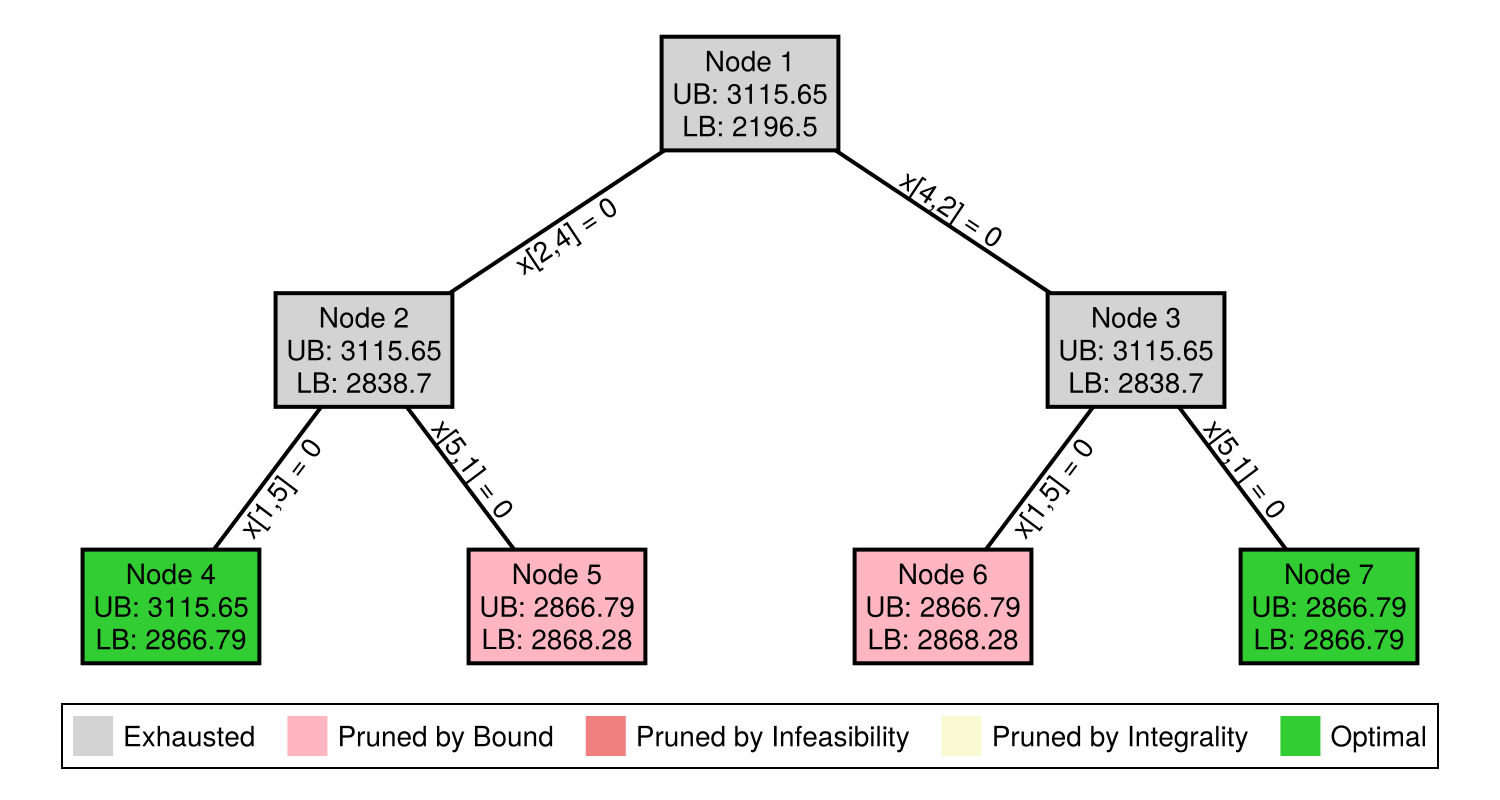

In [13]:
using BnB       # BnB Framework
using JuMP      # Modeling language
using HiGHS     # Solver
using CSV       # Data handling
using Distances # Distance computations

# Structure to represent the TSP data
struct TSPData <: BnB.BnBData
    coordinates::Matrix{Float64}     # City coordinates
    distance_matrix::Matrix{Float64} # Precomputed distance matrix
    n::Int                           # Number of cities
    # Constructor
    function TSPData(;file_path::String)
        coordinates = CSV.read(file_path, CSV.Tables.matrix, header=false)
        distance_matrix = Distances.pairwise(Distances.Haversine(), coordinates, dims=1)
        return new(coordinates, distance_matrix, size(coordinates, 1))
    end
end

# Structure to represent the branch constraint
struct FixVariable <: BnB.BnBBranchConstraint
    i::Int64     # Variable index i 
    j::Int64     # Variable index j
    value::Int64 # Value to fix
end

# Function to find an initial incumbent solution using the Nearest Neighbor heuristic
function BnB.custom_incumbent(data::TSPData)
    visited = falses(data.n)
    solution = zeros(Int, data.n)
    # Start from the first city
    current_city = 1
    solution[1] = current_city
    visited[current_city] = true
    incumbent_objective = 0.0
    for k in 2:data.n
        # Find the nearest unvisited city
        next_city = argmin([visited[j] ? Inf : data.distance_matrix[current_city, j] for j in 1:data.n])
        solution[k] = next_city
        visited[next_city] = true
        incumbent_objective += data.distance_matrix[current_city, next_city]
        current_city = next_city
    end
    # Add the distance to return to the starting city
    incumbent_objective += data.distance_matrix[current_city, solution[1]]
    return BnB.BnBSolution(solution=solution, objective=incumbent_objective)
end

# Function to solve the LP relaxation of the TSP for a given node
function BnB.custom_relaxation(node::BnB.BnBNode, bnb::BnB.BnBCore)
    model = JuMP.Model(HiGHS.Optimizer)
    JuMP.set_silent(model)
    @variable(model, x[i in 1:bnb.data.n, j in 1:bnb.data.n], Bin)
    @objective(model, Min, sum(bnb.data.distance_matrix[i, j] * x[i, j] for i in 1:bnb.data.n, j in 1:bnb.data.n))
    @constraint(model, [i in 1:bnb.data.n], x[i, i] == 0)
    @constraint(model, [j in 1:bnb.data.n], sum(x[i, j] for i in 1:bnb.data.n) == 1)
    @constraint(model, [i in 1:bnb.data.n], sum(x[i, j] for j in 1:bnb.data.n) == 1)
    # Add constraints for fixed variables
    for branch in node.branch_constraints
        @constraint(model, x[branch.i, branch.j] == branch.value)
    end
    JuMP.optimize!(model)
    if JuMP.termination_status(model) == JuMP.OPTIMAL
        # Extract the routes from the solution
        x_val = JuMP.value.(x)
        # Identify cycles in the solution to check for integrality and to identify subtours
        visited = fill(false, bnb.data.n)
        cycles = Vector{Vector{Int}}()
        for start in 1:bnb.data.n
            if !visited[start]
                cycle = Int[start]
                visited[start] = true
                nxt = findfirst(x_val[start, :] .> 0.5)
                while nxt !== nothing && !visited[nxt]
                    push!(cycle, nxt)
                    visited[nxt] = true
                    nxt = findfirst(x_val[nxt, :] .> 0.5)
                end
                push!(cycles, cycle)
            end
        end
        # return cycles, JuMP.objective_value(model)
        return BnB.BnBSolution(solution=cycles, objective=JuMP.objective_value(model))
    end
end

# Function to check pruning conditions for a given node and update its status accordingly
function BnB.custom_prune(node::BnB.BnBNode, bnb::BnB.BnBCore)
    # 1. Prune by Infeasibility
    if isnothing(node.relaxation.objective)
        return BnB.PrunedByInfeasibility
    end
    # 2. Prune by Integrality
    if length(node.relaxation.solution) == 1
        return BnB.PrunedByIntegrality
    end
    # 3. Prune by Bound
    if node.relaxation.objective >= bnb.incumbent.objective
        return BnB.PrunedByBound
    end
    return BnB.Active
end

# Function to select the branches and the values to fix for a given node
function BnB.custom_branch(node::BnB.BnBNode, bnb::BnB.BnBCore)
    # Create two branches: one excluding the edge and one including the edge
    branch_constraints = Vector{BnB.BnBBranchConstraint}()
    # Sort cycles by length to prioritize branching on the smallest subtour
    subtours = sort(node.relaxation.solution, by=length)
    # Select the first edge of the smallest subtour for branching
    for subtour in subtours
        # Iterate through the edges of the subtour and find the first edge that is not already fixed to 0.0 in the current node
        for i in 1:(length(subtour) - 1)
            left_branch = FixVariable(subtour[i], subtour[i+1], 0)
            right_branch = FixVariable(subtour[i+1], subtour[i], 0)
            # Check if the edge is already fixed to 0 in the current node
            if left_branch in node.branch_constraints || right_branch in node.branch_constraints
                continue
            end
            push!(branch_constraints, left_branch)  # Left branch: exclude the edge
            push!(branch_constraints, right_branch) # Right branch: exclude the reverse edge
            return branch_constraints
        end
    end
end

# Function to determine if a node contains an optimal solution
function BnB.custom_is_optimal_solution(node::BnB.BnBNode, bnb::BnB.BnBCore)
    # Check if the node has a valid solution
    if isnothing(node.relaxation.solution)
        return false
    end
    # Check if the solution is integral (i.e., forms a single cycle)
    is_integral = length(node.relaxation.solution) == 1
    # Check if the relaxation value matches the best incumbent objective value within a tolerance
    is_optimal = isapprox(node.relaxation.objective, bnb.incumbent.objective; atol=1e-6)
    # A node is considered optimal if it has an integral solution and its relaxation value matches the incumbent objective value
    if is_integral && is_optimal
        return true
    end
    return false
end

# Example
data = TSPData(file_path="data/tsp_instance.csv")

# Define plot options for this example
custom_plot_options = BnB.BnBPlotOptions(
    figure_size = (750, 400),
    node_size = (140, 90),
    node_label_size = 14,
    edge_label_size = 14,
    show_legend = true,
    legend_position = :bottom,
    branch_label = (branch::FixVariable) -> "x[$(branch.i),$(branch.j)] = $(branch.value)"
)

# Solve the TSP using the BnB framework
solution = BnB.solve(data, is_maximization = false, search_strategy = :best_bound, custom_plot_options = custom_plot_options);

---

## Exercise 8.3

Solve the Maximum Independent Set Problem (MISP) using the Branch-and-Bound technique. Use the dataset [icosahedral.csv](data/icosahedral.csv) as input. The following image illustrates the graph instance.

<div align="center">

![MISP instance for the Branch-and-Bound exercise.](images/Chapter8-exercise3.png)

</div>

### a) Solve the MISP using Branch-and-Bound with Best Bound search strategy.

========== Branch-and-Bound Completed ==========

Total time: 0.28378987312316895 seconds
Best solution: Set([5, 3, 1])
Objective value: 3.0

Nodes explored: 23
Nodes pruned: 3
Pruning statistics:
	- Pruned by infeasibility: 0
	- Pruned by integrality: 2
	- Pruned by bound: 1

Search Tree

└── Node 1 (6.0) 
    ├── Node 2 (5.5) 
    │   ├── Node 4 (5.0) 
    │   │   ├── Node 6 (4.5) 
    │   │   │   ├── Node 8 (4.0) 
    │   │   │   │   ├── Node 14 (3.5) 
    │   │   │   │   │   ├── Node 20 (3.0) ⭐
    │   │   │   │   │   └── Node 21 (2.0) 🔒
    │   │   │   │   └── Node 15 (2.5) ✂️
    │   │   │   └── Node 9 (3.0) ⭐
    │   │   └── Node 7 (3.5) 
    │   │       ├── Node 16 (3.0) ⭐
    │   │       └── Node 17 (3.0) ⭐
    │   └── Node 5 (4.0) 
    │       ├── Node 10 (3.5) 
    │       │   ├── Node 22 (3.0) ⭐
    │       │   └── Node 23 (3.0) ⭐
    │       └── Node 11 (3.0) ⭐
    └── Node 3 (4.0) 
        ├── Node 12 (3.5) 
        │   ├── Node 18 (3.0) ⭐
        │   └── Node 19 (2.0) 🔒


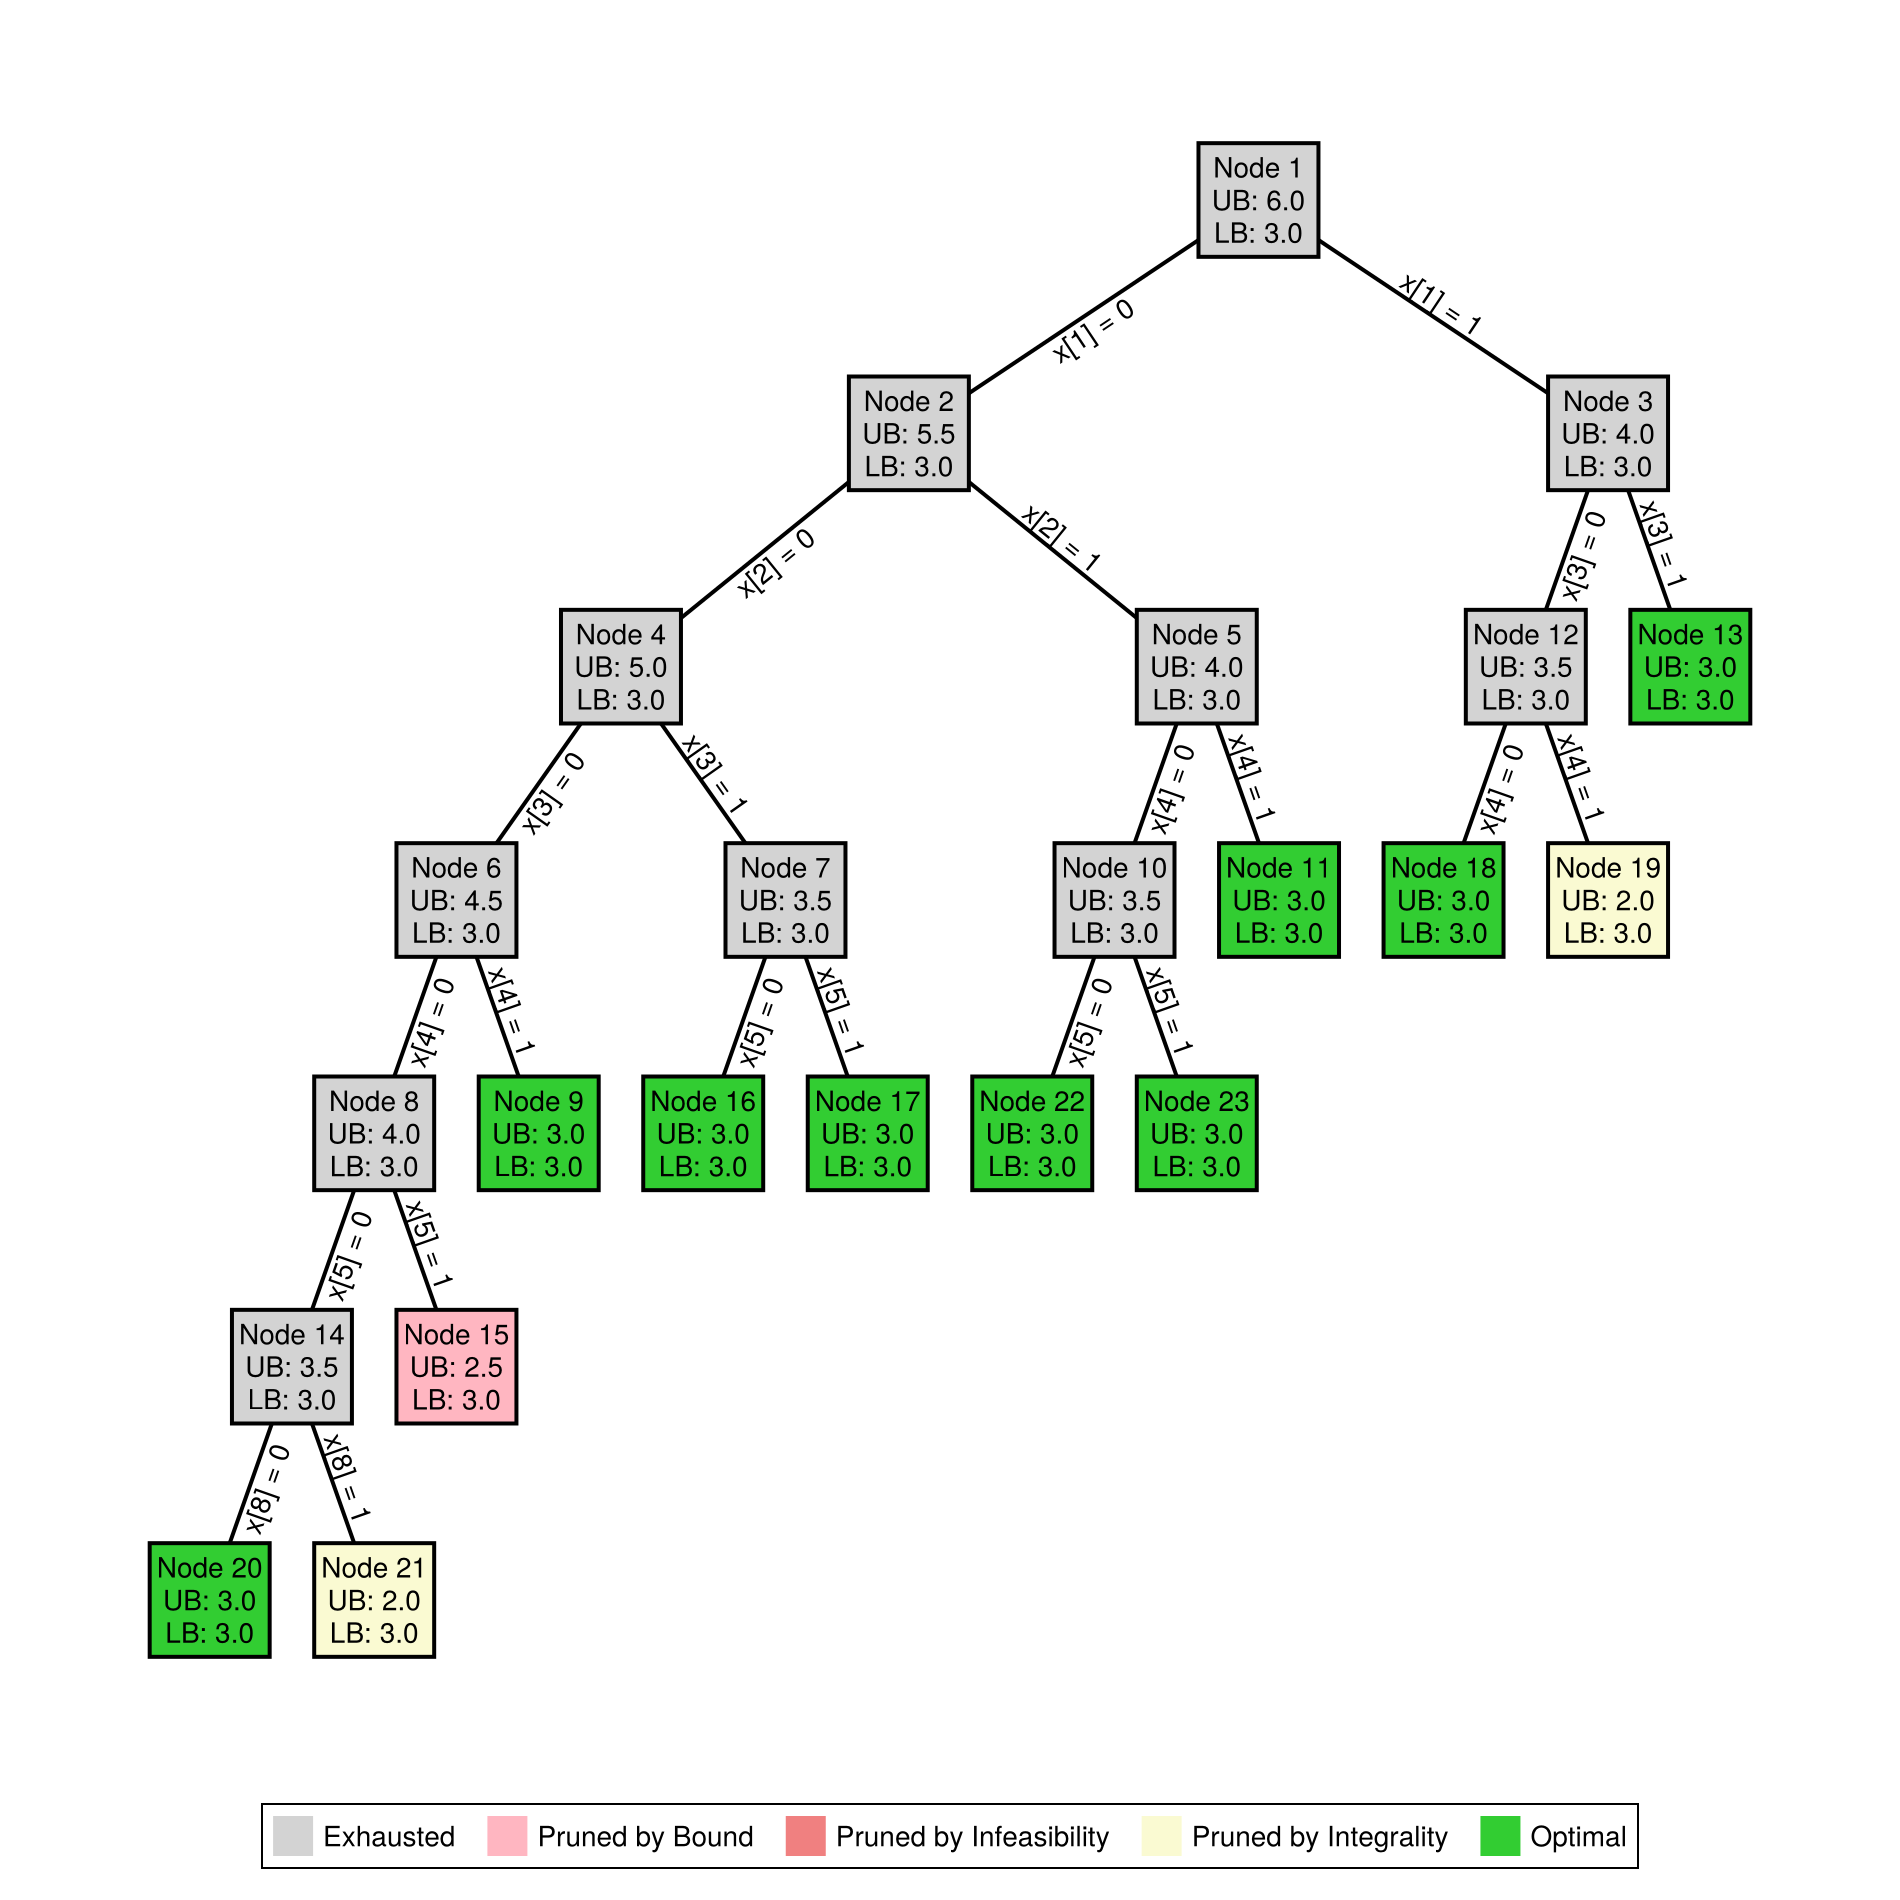

In [14]:
using BnB    # BnB Framework
using JuMP   # Modeling language
using HiGHS  # Solver
using Graphs # Graphs package

# Structure to represent the MISP data
struct MISPData <: BnB.BnBData
    graph::Graphs.SimpleGraph # Graph structure
    n::Int64                  # Number of vertices
    m::Int64                  # Number of edges
    # Constructor
    function MISPData(graph::Graphs.SimpleGraph)
        n = Graphs.nv(graph)
        m = Graphs.ne(graph)
        return new(graph, n, m)
    end
end

# Structure to represent the branch constraint
struct FixVariable <: BnB.BnBBranchConstraint
    v::Int64     # Variable index
    value::Int64 # Value to fix
end

# Function to find an initial incumbent solution using a greedy heuristic
function BnB.custom_incumbent(data::MISPData)
    graph = data.graph
    n = data.n
    # Initialize the independent set and a set to track selected vertices
    independent_set = Set{Int}()
    selected = falses(n)
    # Iterate over vertices in order of degree (lowest degree first)
    for v in sort(1:n, by=v -> Graphs.degree(graph, v))
        if !selected[v]
            push!(independent_set, v)
            selected[v] = true
            # Mark neighbors as selected to prevent their inclusion
            for neighbor in Graphs.neighbors(graph, v)
                selected[neighbor] = true
            end
        end
    end
    return BnB.BnBSolution(solution=independent_set, objective=length(independent_set))
end

# Function to solve the LP relaxation of the MISP for a given node
function BnB.custom_relaxation(node::BnB.BnBNode, bnb::BnB.BnBCore)
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    # Define the decision variables
    @variable(model, 0 <= x[v in 1:bnb.data.n] <= 1)
    # Objective function: maximize the total of selected vertices
    @objective(model, Max, sum(x[v] for v in 1:bnb.data.n))
    # Independence constraint
    for e in Graphs.edges(bnb.data.graph)
        @constraint(model, x[e.src] + x[e.dst] <= 1)
    end
    # Add constraints for fixed variables
    for branch in node.branch_constraints
        @constraint(model, x[branch.v] == branch.value)
    end
    # Run the solver
    JuMP.optimize!(model)
    if JuMP.termination_status(model) == JuMP.OPTIMAL
        return BnB.BnBSolution(solution=JuMP.value.(x), objective=JuMP.objective_value(model))
    end
end

# Function to check pruning conditions for a given node and update its status accordingly
function BnB.custom_prune(node::BnB.BnBNode, bnb::BnB.BnBCore)
    # 1. Prune by Infeasibility
    if isnothing(node.relaxation.solution)
        return BnB.PrunedByInfeasibility
    end
    # 2. Prune by Integrality
    if !any(x -> 1e-5 < x < (1 - 1e-5), node.relaxation.solution)
        return BnB.PrunedByIntegrality
    end
    # 3. Prune by Bound
    if node.relaxation.objective <= bnb.incumbent.objective
        return BnB.PrunedByBound
    end
    return BnB.Active
end

# Function to select the branches and the values to fix for a given node
function BnB.custom_branch(node::BnB.BnBNode, bnb::BnB.BnBCore)
    # Create two branches: one excluding the edge and one including the edge
    branch_constraints = Vector{BnB.BnBBranchConstraint}()
    # Find all fractional variables in the solution
    fractional_variables = findall(x -> 1e-5 < x < (1 - 1e-5), node.relaxation.solution)
    # Create branches
    for var in fractional_variables
        left_branch = FixVariable(var, 0)
        right_branch = FixVariable(var, 1)
        # Check if the variable is already fixed in the current node
        if left_branch in node.branch_constraints || right_branch in node.branch_constraints
            continue
        end
        push!(branch_constraints, left_branch)  # Left branch: exclude the vertice
        push!(branch_constraints, right_branch) # Right branch: include the vertice
        return branch_constraints
    end
end

# Function to determine if a node is optimal by checking if it has an integral solution and if its relaxation value matches the incumbent objective value
function BnB.custom_is_optimal_solution(node::BnB.BnBNode, bnb::BnB.BnBCore)
    # Check if the node has a valid solution
    if isnothing(node.relaxation.solution)
        return false
    end
    # Check if the solution is integral (i.e., all variables are either 0 or 1)
    is_integral = !any(x -> 1e-5 < x < (1 - 1e-5), node.relaxation.solution)
    # Check if the relaxation value matches the best incumbent objective value within a tolerance
    is_optimal = isapprox(node.relaxation.objective, bnb.incumbent.objective; atol=1e-6)
    # It is optimal if it has an integral solution and its relaxation value matches the incumbent objective value
    if is_integral && is_optimal
        return true
    end
    return false
end

# Example
graph = Graphs.smallgraph("icosahedral")
data = MISPData(graph)

# Define plot options for this example
custom_plot_options = BnB.BnBPlotOptions(
    figure_size = (950, 950),
    node_size = (95, 90),
    node_label_size = 14,
    edge_label_size = 14,
    show_legend = true,
    legend_position = :bottom,
    branch_label = (branch::FixVariable) -> "x[$(branch.v)] = $(branch.value)"
)

# Solve the MISP using the BnB framework
solution = BnB.solve(data, is_maximization = true, search_strategy = :best_bound, custom_plot_options = custom_plot_options);

### b) Solve the MISP using Branch-and-Cut technique.

========== Branch-and-Bound Completed ==========

Total time: 0.5160820484161377 seconds
Best solution: Set([5, 3, 1])
Objective value: 3.0

Nodes explored: 13
Nodes pruned: 0
Pruning statistics:
	- Pruned by infeasibility: 0
	- Pruned by integrality: 0
	- Pruned by bound: 0

Cuts generated: 14

Search Tree

└── Node 1 (6.0) 
    ├── Node 2 (3.83) 
    │   ├── Node 4 (3.5) 
    │   │   ├── Node 10 (3.5) 
    │   │   │   ├── Node 12 (3.0) ⭐
    │   │   │   └── Node 13 (3.0) ⭐
    │   │   └── Node 11 (3.0) ⭐
    │   └── Node 5 (3.5) 
    │       ├── Node 8 (3.0) ⭐
    │       └── Node 9 (3.0) ⭐
    └── Node 3 (3.5) 
        ├── Node 6 (3.0) ⭐
        └── Node 7 (3.0) ⭐

Legend:

	🔒 : Pruned by Integrality
	🚫 : Pruned by Infeasibility
	✂️ : Pruned by Bound
	⭐ : Optimal



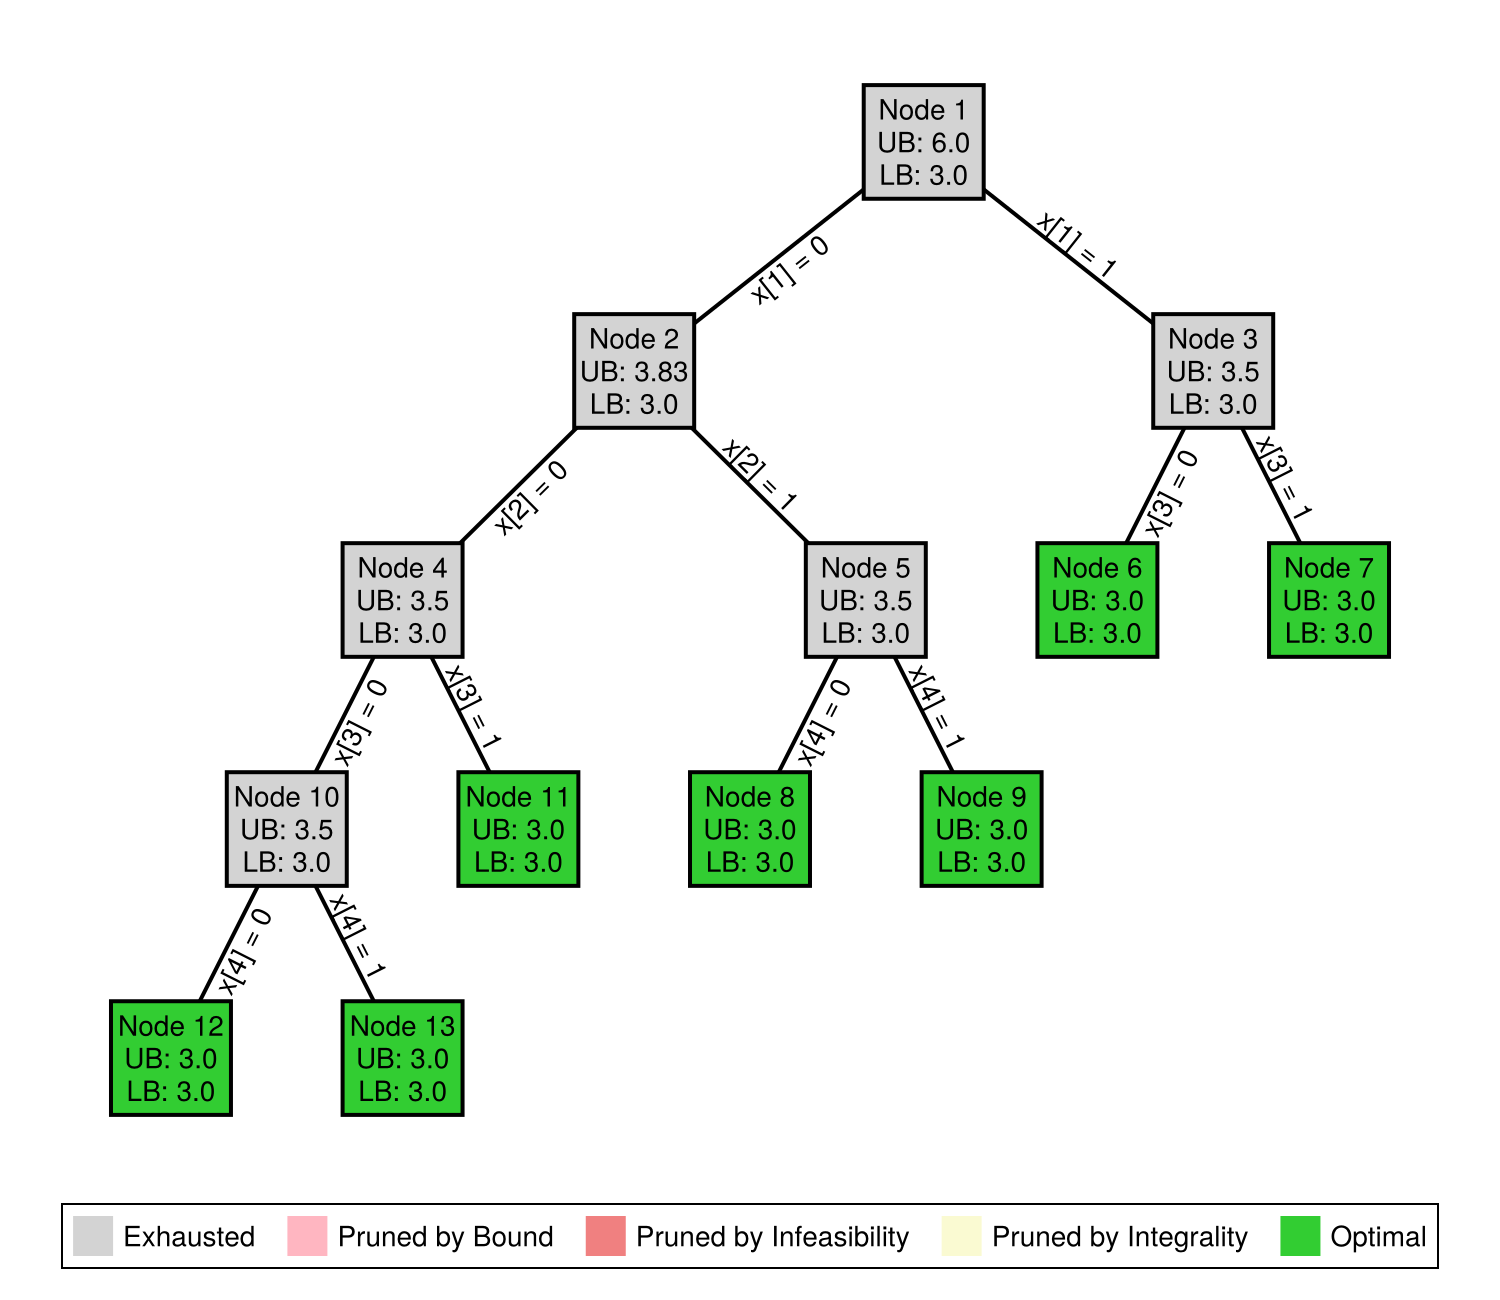

In [15]:
using BnB    # BnB Framework
using JuMP   # Modeling language
using HiGHS  # Solver
using Graphs # Graphs package
using Random # For random shuffling in the heuristic

# Structure to represent the MISP data
struct MISPData <: BnB.BnBData
    graph::Graphs.SimpleGraph # Graph structure
    n::Int64                  # Number of vertices
    m::Int64                  # Number of edges
    # Constructor
    function MISPData(graph::Graphs.SimpleGraph)
        n = Graphs.nv(graph)
        m = Graphs.ne(graph)
        return new(graph, n, m)
    end
end

# Structure to represent the branch constraint
struct FixVariable <: BnB.BnBBranchConstraint
    v::Int64     # Variable index
    value::Int64 # Value to fix
end

# Function to find an initial incumbent solution using a greedy heuristic
function BnB.custom_incumbent(data::MISPData)
    graph = data.graph
    # Initialize the independent set and a set to track selected vertices
    independent_set = Set{Int}()
    selected = falses(data.n)
    # Iterate over vertices in order of degree (lowest degree first)
    for v in sort(1:data.n, by=v -> Graphs.degree(graph, v))
        if !selected[v]
            push!(independent_set, v)
            selected[v] = true
            # Mark neighbors as selected to prevent their inclusion
            for neighbor in Graphs.neighbors(graph, v)
                selected[neighbor] = true
            end
        end
    end
    return BnB.BnBSolution(solution=independent_set, objective=length(independent_set))
end

# A simple heuristic to find a violated clique inequalities
function find_violated_cliques_multi(g, x; K=10)
    n = nv(g)
    cliques = Set{Set{Int}}()
    base = filter(v -> x[v] > 1e-4, 1:n)
    # Try multiple random orders to find different violated cliques
    for seed in 1:K
        # Random order of candidates to get different cliques in each iteration
        candidates = copy(base)
        shuffle!(candidates)
        sort!(candidates, by=v->x[v], rev=true)
        clique = Set{Int}()
        weight = 0.0
        for v in candidates
            if all(u -> has_edge(g,u,v), clique)
                push!(clique, v)
                weight += x[v]
            end
        end
        # Only consider cliques of size >= 3 that violate the inequality
        if length(clique) >= 3 && weight > 1 + 1e-4
            push!(cliques, clique)
        end
    end
    return cliques
end

# Function to solve the relaxation of the MISP for a given node using Cutting Planes
function BnB.custom_relaxation(node::BnB.BnBNode, bnb::BnB.BnBCore)
    # Create the model
    model = JuMP.Model(HiGHS.Optimizer)
    # Silent mode (solver output is not printed)
    JuMP.set_silent(model)
    # Define the decision variables
    @variable(model, 0 <= x[v in 1:bnb.data.n] <= 1)
    # Objective function
    @objective(model, Max, sum(x[v] for v in 1:bnb.data.n))
    # Base Independence constraint (Edge Constraints)
    for e in Graphs.edges(bnb.data.graph)
        @constraint(model, x[e.src] + x[e.dst] <= 1)
    end
    # Add constraints for fixed variables from the BnB node
    for branch in node.branch_constraints
        @constraint(model, x[branch.v] == branch.value)
    end
    # Add cutting planes
    for clique in bnb.global_cuts
        @constraint(model, sum(x[v] for v in clique) <= 1)
    end
    # Run the solver
    JuMP.optimize!(model)
    # Check for violated clique constraints and add them to the global cut pool
    violated_cliques = find_violated_cliques_multi(bnb.data.graph, JuMP.value.(x), K=20)
    for violated_clique in violated_cliques
        if !isempty(violated_clique) && !(violated_clique in bnb.global_cuts)
            push!(bnb.global_cuts, violated_clique)
        end
    end
    if JuMP.termination_status(model) == JuMP.OPTIMAL
        return BnB.BnBSolution(solution=JuMP.value.(x), objective=JuMP.objective_value(model))
    end
end

# Function to check pruning conditions for a given node and update its status accordingly
function BnB.custom_prune(node::BnB.BnBNode, bnb::BnB.BnBCore)
    # 1. Prune by Infeasibility
    if isnothing(node.relaxation.solution)
        return BnB.PrunedByInfeasibility
    end
    # 2. Prune by Integrality
    if !any(x -> 1e-5 < x < (1 - 1e-5), node.relaxation.solution)
        return BnB.PrunedByIntegrality
    end
    # 3. Prune by Bound
    if node.relaxation.objective <= bnb.incumbent.objective
        return BnB.PrunedByBound
    end
    return BnB.Active
end

# Function to select the branches and the values to fix for a given node
function BnB.custom_branch(node::BnB.BnBNode, bnb::BnB.BnBCore)
    # Create two branches: one excluding the edge and one including the edge
    branch_constraints = Vector{BnB.BnBBranchConstraint}()
    # Find all fractional variables in the solution
    fractional_variables = findall(x -> 1e-5 < x < (1 - 1e-5), node.relaxation.solution)
    # Create branches
    for var in fractional_variables
        left_branch = FixVariable(var, 0)
        right_branch = FixVariable(var, 1)
        # Check if the variable is already fixed in the current node
        if left_branch in node.branch_constraints || right_branch in node.branch_constraints
            continue
        end
        push!(branch_constraints, left_branch)  # Left branch: exclude the vertice
        push!(branch_constraints, right_branch) # Right branch: include the vertice
        return branch_constraints
    end
end

# Function to determine if a node contains an optimal solution
function BnB.custom_is_optimal_solution(node::BnB.BnBNode, bnb::BnB.BnBCore)
    # Check if the node has a valid solution
    if isnothing(node.relaxation.solution)
        return false
    end
    # Check if the solution is integral (i.e., all variables are either 0 or 1)
    is_integral = !any(x -> 1e-5 < x < (1 - 1e-5), node.relaxation.solution)
    # Check if the relaxation value matches the best incumbent objective value within a tolerance
    is_optimal = isapprox(node.relaxation.objective, bnb.incumbent.objective; atol=1e-6)
    # It is optimal if it has an integral solution and its relaxation value matches the incumbent objective value
    if is_integral && is_optimal
        return true
    end
    return false
end

# Example
graph = Graphs.smallgraph("icosahedral")
data = MISPData(graph)

# Define plot options for this example
custom_plot_options = BnB.BnBPlotOptions(
    figure_size = (750, 650),
    node_size = (95, 90),
    node_label_size = 14,
    edge_label_size = 14,
    show_legend = true,
    legend_position = :bottom,
    branch_label = (branch::FixVariable) -> "x[$(branch.v)] = $(branch.value)"
)

# Solve the MISP using the BnB framework
Random.seed!(42) # Set a random seed for reproducibility
solution = BnB.solve(data, is_maximization = true, search_strategy = :best_bound, custom_plot_options = custom_plot_options);

### c) Compare the results obtained in exercises a) and b). What is the advantage of using the Branch-and-Price technique?

<div align="center">

| Metric          | Branch-and-Bound | Branch-and-Cut |
| --------------- | ---------------- | -------------- |
| Objective value | 3.0              | 3.0            |
| Time            | 0.384 s          | 0.551 s        |
| Nodes explored  | 23               | 13             |
| Nodes pruned    | 3                | 0              |
| Cuts generated  | 0                | 14             |

</div>

The generated cuts significantly strengthened the LP relaxation, reducing the number of explored nodes from 23 to 13. However, the computational overhead associated with generating and separating 18 cuts outweighed the reduction in tree size, resulting in a longer overall runtime. Therefore, while Branch-and-Cut produced a smaller search tree, it did not provide a runtime advantage on this small instance. The benefits of Branch-and-Cut would be expected to become more pronounced on larger and more difficult MISP instances, where the stronger relaxation can substantially reduce the size of the branch-and-bound tree.